# RAFT Training Data Exploration

This notebook provides a comprehensive exploration of the RAFT (Retrieval-Augmented Fine-Tuning) training dataset generated by `raft_datagen.py`. The primary goals are:

1. **Validate generation quality** — confirm that oracle/distractor ratios and answer formats are correct.
2. **Determine `max_new_tokens`** — by analysing the distribution of CoT answer lengths.
3. **Determine `max_seq_length`** — by analysing the distribution of full instruction (context + question) lengths.

## Dataset Overview

The RAFT dataset is stored in `data/training_data_raft/raw` as three JSONL splits:

| Split | File | Purpose |
|-------|------|---------|
| Train | `train.jsonl` | Fine-tuning examples (80 %) |
| Validation | `validation.jsonl` | In-training evaluation / early stopping (10 %) |
| Test | `test.jsonl` | Held-out evaluation (10 %) |

Each record contains:

| Field | Description |
|-------|-------------|
| `question` | A factual question derived from a source document chunk |
| `context` | Retrieved passages — one oracle chunk + three distractor chunks, shuffled |
| `oracle_context` | The specific chunk containing the correct answer |
| `cot_answer` | Chain-of-thought answer with `##begin_quote##` citations and a final `<ANSWER>:` tag |
| `instruction` | Fully formatted model input: `<DOCUMENT>` blocks + question |
| `type` | `"oracle"` (answer chunk present) or `"distractor"` (answer chunk withheld) |

## Notebook Sections

1. Load Dataset  
2. Dataset Balance: Oracle vs Distractor  
3. CoT Answer Length Analysis → guides `max_new_tokens`  
4. Instruction (Context) Length Analysis → guides `max_seq_length`  
5. Persist Computed Columns

## 1. Load Dataset

Load the three JSONL splits into Pandas DataFrames and verify row counts. The 80/10/10 split is produced by `raft_datagen.py` at generation time.

In [ ]:
# load training data from training_data_raft
import pandas as pd
import os
dir = "./data/training_data_raft/raw"
train_df = pd.read_json(os.path.join(dir, "train.jsonl"), lines=True)
test_df = pd.read_json(os.path.join(dir, "test.jsonl"), lines=True)
validation_df = pd.read_json(os.path.join(dir, "validation.jsonl"), lines=True)
print(f"Number of samples: train={len(train_df)}, test={len(test_df)}")
train_df.head()

Number of samples: train=521, test=66


,id,type,question,context,oracle_context,cot_answer,instruction
0,seed_task_139,oracle,Who owns the trademark for ServiceNow?,"{'sentences': [['--- © 2025 ServiceNow, Inc. ...","---\n\n© 2025 ServiceNow, Inc. All rights rese...",Step-by-step reasoning:\n\n1. The question ask...,"<DOCUMENT>---\n\n© 2025 ServiceNow, Inc. All r..."
1,seed_task_53,distractor,What does the Machine Identity Console display?,{'sentences': [['## Data processing in product...,### Ensure each user has a unique user account...,Step-by-step reasoning:\n\n1. **Understand the...,<DOCUMENT>## Data processing in production\nWh...
2,seed_task_47,oracle,What user access patterns should be accounted ...,{'sentences': [['- Employ Adaptive Authenticat...,- Employ Adaptive Authentication to enforce ac...,Step-by-step reasoning:\n\n1. **Understand the...,<DOCUMENT>- Employ Adaptive Authentication to ...
3,seed_task_44,oracle,How does the MFA dashboard help improve instan...,{'sentences': [['```markdown # Compliance: Reg...,```markdown\n# Best practices continued\n\n## ...,"To answer the question ""How does the MFA dashb...",<DOCUMENT>```markdown\n# Compliance: Regulator...
4,seed_task_19,oracle,What does the DSA cover in the ServiceNow AI P...,{'sentences': [['### Best practices #### Unde...,```markdown\n# Compliance: Regulatory and lega...,Step-by-step reasoning:\n\n1. **Understand the...,<DOCUMENT>### Best practices\n\n#### Understan...


## 2. Dataset Balance: Oracle vs Distractor

Each sample is labelled `"oracle"` (the correct chunk is present in the retrieved context) or `"distractor"` (the oracle chunk is withheld). The RAFT methodology targets roughly **80 % oracle / 20 % distractor** — this trains the model to extract evidence when it is available and to refuse gracefully when it is not.

Verify that the generation script produced the expected balance across all three splits.

In [ ]:
print(train_df["type"].value_counts())
print(test_df["type"].value_counts())
print(validation_df["type"].value_counts())

# % of examples where the oracle chunk is included in the context
print("Train oracle chunk inclusion rate:", (train_df["type"] == "oracle").mean())
print("Test oracle chunk inclusion rate:", (test_df["type"] == "oracle").mean())
print("Validation oracle chunk inclusion rate:", (validation_df["type"] == "oracle").mean())

type
oracle        415
distractor    106
Name: count, dtype: int64
type
oracle        58
distractor     8
Name: count, dtype: int64
type
oracle        56
distractor     9
Name: count, dtype: int64
Train oracle chunk inclusion rate: 0.7965451055662188
Test oracle chunk inclusion rate: 0.8787878787878788
Validation oracle chunk inclusion rate: 0.8615384615384616


### 2.1 Sample Oracle Example

Inspect a single oracle-type record to verify the CoT answer format. A well-formed answer should:
- Cite evidence with `##begin_quote##...##end_quote##` markers drawn verbatim from the context
- End with a concise `<ANSWER>: ...` tag containing the final response

In [ ]:
sample_oracle = train_df[train_df["type"]== "oracle"].iloc[0]
print("Question:", sample_oracle["question"])
print("COT Answer:", sample_oracle["cot_answer"])

Question: Who owns the trademark for ServiceNow?
COT Answer: Step-by-step reasoning:

1. The question asks about who owns the trademark for ServiceNow.
2. I will look for any mention of trademarks or ownership in the provided context.
3. In the context, I found the following relevant information:  
   ##begin_quote##  
   "ServiceNow, the ServiceNow logo, and other ServiceNow marks are trademarks and/or registered trademarks of ServiceNow, Inc. in the United States and/or other countries."  
   ##end_quote##  
4. This sentence clearly states that the trademarks for ServiceNow are owned by ServiceNow, Inc.
5. Since the context provides the required information, I can confidently answer the question.

<ANSWER>: ServiceNow, Inc. owns the trademark for ServiceNow! 😊


### 2.2 Sample Distractor Example

In a distractor example the oracle chunk is **absent** from the context. The model should respond that it cannot determine the answer from the provided documents. This teaches robustness against hallucination when retrieval fails.

In [ ]:
sample_distractor = train_df[train_df["type"]== "distractor"].iloc[0]
print("Question:", sample_distractor["question"])

print("Context sentences:\n\n")
print("="*50)
for sentence in sample_distractor["context"]["sentences"][0]:
    print("-", sentence)

print("COT Answer:", sample_distractor["cot_answer"])

Question: What does the Machine Identity Console display?
Context sentences:


- ## Data processing in production
When using generative AI services, prompts and responses are processed in memory only—inputs and outputs are not stored or cached by the inference infrastructure. For details on how data is transmitted, processed, and protected during runtime, refer to the [Data Processing for Advanced AI & Data Products FAQ (KB1584492)](https://www.servicenow.com/kb/article?sys_kb_id=kb1584492).

Evaluate how AI data is securely processed and select either ServiceNow-hosted or third-party LLMs in alignment with your organization’s data residency and governance policies.

*Note:* Third-party LLMs may use global infrastructure to dynamically route traffic to the best available data center for each request. This means the regional processing location may differ from the data center region specified on a customer’s order form.
- Establish a process involving relevant stakeholders to review the

## 3. CoT Answer Length Analysis

Understanding the distribution of CoT answer lengths (measured in whitespace-delimited words) is critical for setting `max_new_tokens` during fine-tuning and inference.

> **Analysis scope:** restricted to **oracle-type** examples only. Distractor answers are intentionally terse ("I cannot answer from the provided context") and would skew the distribution toward zero.

**Guidance:** a reasonable `max_new_tokens` should cover at least the **95th percentile** of the oracle answer word count. Multiply by ~1.3 to convert words to sub-word tokens.

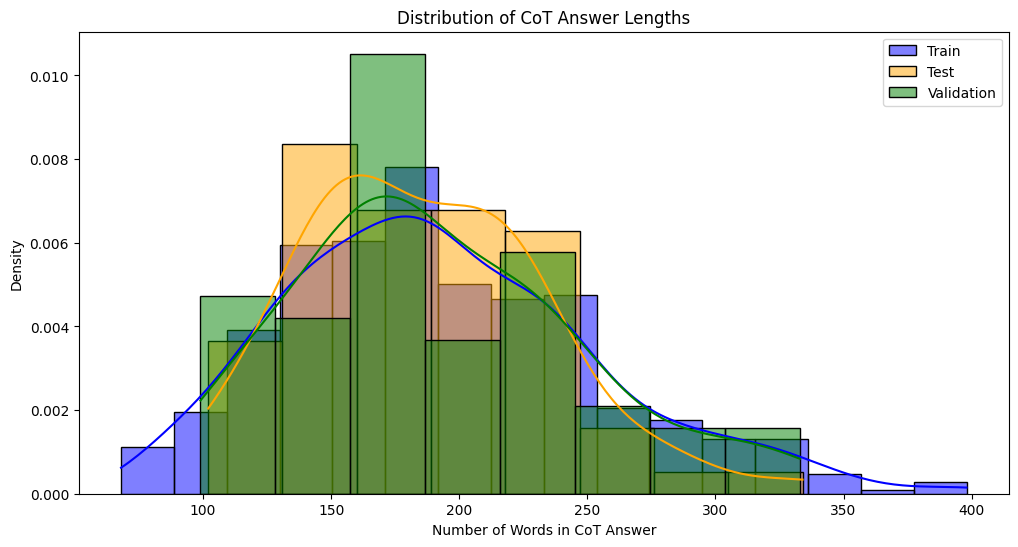

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

train_df["cot_answer_length"] = train_df["cot_answer"].apply(lambda x: len(x.split()))
test_df["cot_answer_length"] = test_df["cot_answer"].apply(lambda x: len(x.split()))
validation_df["cot_answer_length"] = validation_df["cot_answer"].apply(lambda x: len(x.split()))
plt.figure(figsize=(12, 6))
sns.histplot(train_df["cot_answer_length"], color="blue", label="Train", kde=True, stat="density")
sns.histplot(test_df["cot_answer_length"], color="orange", label="Test", kde=True, stat="density")
sns.histplot(validation_df["cot_answer_length"], color="green", label="Validation", kde=True, stat="density")
plt.title("Distribution of CoT Answer Lengths")
plt.xlabel("Number of Words in CoT Answer")
plt.legend()
plt.show()

### 3.1 Percentile Statistics

Compute descriptive statistics with key percentiles to identify a safe `max_new_tokens` cutoff.

In [ ]:
# order by length and look at percentiles for train, test, and validation sets
print("Train CoT answer length percentiles:")
print(train_df[train_df["type"] == "oracle"]["cot_answer_length"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))
print("\nTest CoT answer length percentiles:")
print(test_df[test_df["type"] == "oracle"]["cot_answer_length"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))
print("\nValidation CoT answer length percentiles:")
print(validation_df[validation_df["type"] == "oracle"]["cot_answer_length"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

Train CoT answer length percentiles:
count    415.000000
mean     193.253012
std       60.399124
min       78.000000
25%      149.000000
50%      189.000000
75%      232.500000
90%      275.600000
95%      309.300000
99%      346.020000
max      398.000000
Name: cot_answer_length, dtype: float64

Test CoT answer length percentiles:
count     58.000000
mean     185.568966
std       47.968964
min      102.000000
25%      152.250000
50%      179.000000
75%      214.500000
90%      241.200000
95%      273.300000
99%      309.490000
max      334.000000
Name: cot_answer_length, dtype: float64

Validation CoT answer length percentiles:
count     56.000000
mean     189.500000
std       58.150588
min       99.000000
25%      152.000000
50%      177.000000
75%      228.250000
90%      273.000000
95%      306.000000
99%      324.200000
max      333.000000
Name: cot_answer_length, dtype: float64


### 3.2 Filtered Distribution (Capped at 512 Words)

A small number of outlier answers are very long. Re-plotting after removing records with more than 512 words reveals the typical distribution more clearly and confirms whether 512 is a reasonable `max_new_tokens` ceiling.

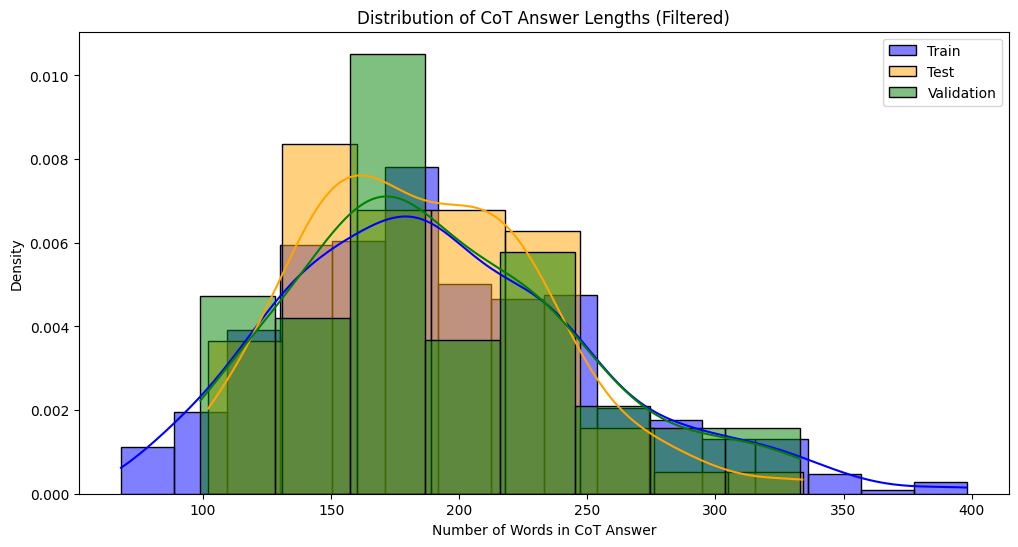

In [ ]:
# remove the outliers with very long answers and look at the distribution again
train_df = train_df[train_df["cot_answer_length"] < 512]
validation_df = validation_df[validation_df["cot_answer_length"] < 512]
test_df = test_df[test_df["cot_answer_length"] < 512]
plt.figure(figsize=(12, 6))
sns.histplot(train_df["cot_answer_length"], color="blue", label="Train", kde=True, stat="density")
sns.histplot(test_df["cot_answer_length"], color="orange", label="Test", kde=True, stat="density")
sns.histplot(validation_df["cot_answer_length"], color="green", label="Validation", kde=True, stat="density")
plt.title("Distribution of CoT Answer Lengths (Filtered)")
plt.xlabel("Number of Words in CoT Answer")
plt.legend()
plt.show()


## 4. Instruction (Context) Length Analysis

The `instruction` field is the full model input: multiple `<DOCUMENT>` blocks (oracle + distractors) followed by the question. Its word-count distribution determines a safe value for `max_seq_length` in the fine-tuning configuration.

> **Important:** samples longer than `max_seq_length` tokens are silently **right-truncated** by the tokeniser, which can clip the question and cause the model to learn from malformed examples.

**Guidance:** set `max_seq_length` ≥ 99th percentile of instruction word count × 1.3 (words-to-tokens expansion factor).

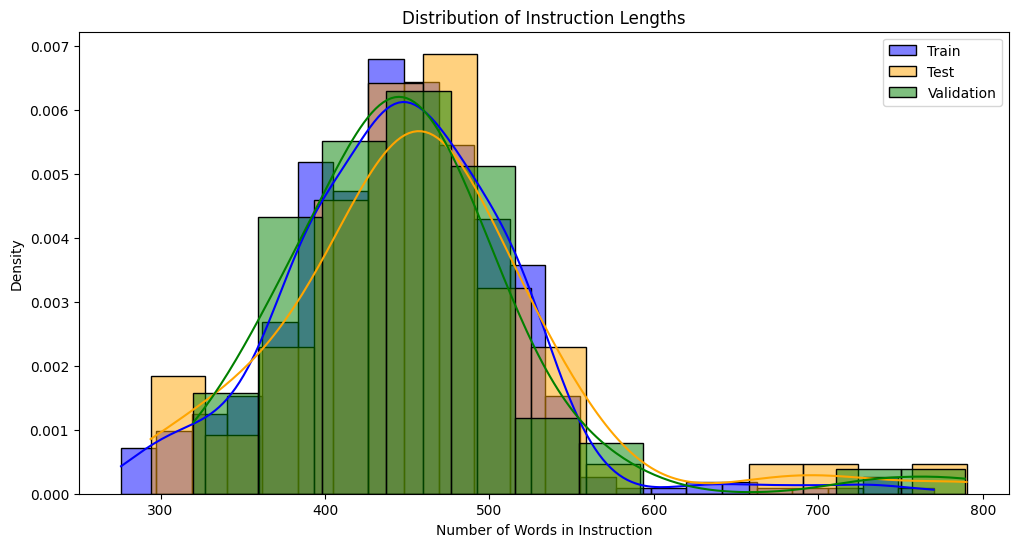

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

train_df["instruction_length"] = train_df["instruction"].apply(lambda x: len(x.split()))
test_df["instruction_length"] = test_df["instruction"].apply(lambda x: len(x.split()))
validation_df["instruction_length"] = validation_df["instruction"].apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 6))
sns.histplot(train_df["instruction_length"], color="blue", label="Train", kde=True, stat="density")
sns.histplot(test_df["instruction_length"], color="orange", label="Test", kde=True, stat="density")
sns.histplot(validation_df["instruction_length"], color="green", label="Validation", kde=True, stat="density")
plt.title("Distribution of Instruction Lengths")
plt.xlabel("Number of Words in Instruction")
plt.legend()
plt.show()


### 4.1 Percentile Statistics

Compute descriptive statistics to determine a safe `max_seq_length`. Pay attention to the 95th and 99th percentiles — multiply by ~1.3 to estimate sub-word token counts.

In [ ]:
print("Train instruction length percentiles:")
print(train_df["instruction_length"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))
print("\nTest instruction length percentiles:")
print(test_df["instruction_length"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))
print("\nValidation instruction length percentiles:")
print(validation_df["instruction_length"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

# Estimate token count at the 99th percentile (words × 1.3 expansion factor)
p99_words = train_df["instruction_length"].quantile(0.99)
print(f"\nTrain 99th percentile: {p99_words:.0f} words ≈ {p99_words * 1.3:.0f} tokens")
print("Recommended max_seq_length:", int(p99_words * 1.3 * 1.1 / 128 + 1) * 128, "(rounded up to nearest 128)")


Train instruction length percentiles:
count    521.000000
mean     446.328215
std       70.133813
min      276.000000
25%      400.000000
50%      446.000000
75%      489.000000
90%      522.000000
95%      539.000000
99%      688.400000
max      770.000000
Name: instruction_length, dtype: float64

Test instruction length percentiles:
count     66.000000
mean     456.833333
std       85.176483
min      294.000000
25%      417.000000
50%      453.000000
75%      488.500000
90%      537.000000
95%      555.750000
99%      739.950000
max      790.000000
Name: instruction_length, dtype: float64

Validation instruction length percentiles:
count     65.000000
mean     450.353846
std       77.671872
min      320.000000
25%      401.000000
50%      440.000000
75%      484.000000
90%      514.800000
95%      551.200000
99%      755.080000
max      789.000000
Name: instruction_length, dtype: float64

Train 99th percentile: 688 words ≈ 895 tokens
Recommended max_seq_length: 1024 (rounded up to ne

## 5. Persist Computed Columns

Write the enriched DataFrames — now including `cot_answer_length` and `instruction_length` — back to the source JSONL files. These columns are useful for downstream filtering (e.g., dropping records that exceed the training context window before fine-tuning).

In [ ]:
# Update JSONL files to include instruction length and cot answer length
dir = "./data/training_data_raft/filtered"
# make sure the directory exists
os.makedirs(dir, exist_ok=True)
train_df.to_json(os.path.join(dir, "train.jsonl"), orient="records", lines=True)
test_df.to_json(os.path.join(dir, "test.jsonl"), orient="records", lines=True)
validation_df.to_json(os.path.join(dir, "validation.jsonl"), orient="records", lines=True)

In [ ]:
MAX_NEW_TOKENS = train_df["cot_answer_length"].max() # 512
MAX_SEQ_LEN = train_df["instruction_length"].max() # around 1600

# Based on the analysis, we can set max_new_tokens to 512 and max_seq_length to around 2048 (to accommodate the longest instructions and answers with some buffer).
print(f"Recommended max_new_tokens: {MAX_NEW_TOKENS}")
print(f"Recommended max_seq_length: {int(MAX_SEQ_LEN * 1.3 * 1.1 / 128 + 1) * 128} (rounded up to nearest 128)")

Recommended max_new_tokens: 398
Recommended max_seq_length: 1152 (rounded up to nearest 128)


## Summary 

Based on the analysis above, the following hyperparameters are suggested for the fine-tuning notebook (`raft-finetuning-slm.ipynb`):

| Parameter | Suggested Value | Rationale |
|-----------|-----------------|-----------|
| `max_new_tokens` | 256 – 512 | Covers ≥ 95th percentile of oracle CoT answer word counts |
| `max_seq_length` | 1024 – 2048 | Covers ≥ 99th percentile of instruction word counts (× 1.3 token expansion) |
| Expected oracle ratio | ~ 0.80 | Verified in Section 2 |